## Main notebook for generating all plots in the honors research distinction thesis

In [131]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics2 as IRSC

import VBMicrolensing
import MulensModel as mm
import os

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (8, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 16
plt.rcParams['ytick.labelsize'] = 16
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

VBM = VBMicrolensing.VBMicrolensing() # Instance to VBMicroLensing

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Figure 1

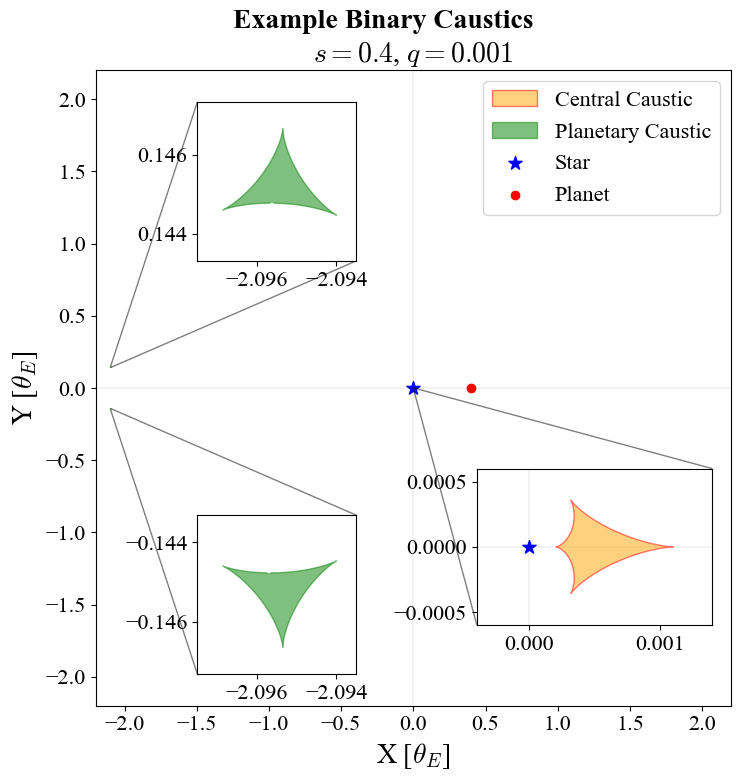

In [253]:
s = 0.4
q = 1e-3

lens_attributes = np.array([
    [0, 0, 1],
    [s, 0, q]
])

caustics = VBM.Caustics(s, q)
caustics = np.array(caustics, dtype=object)

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
center_of_magnification = np.array([q / ((1 + q) * (s + 1/s)), 0])

desired_offset = np.array([0, 0])

lens_attributes[:, :2] -= desired_offset

def plot_elements(target_ax, show_labels=False):
    x_c = caustics[2][0] + center_of_mass[0] - desired_offset[0]
    y_c = caustics[2][1] + center_of_mass[1] - desired_offset[1]
    points = np.array([x_c, y_c]).T
    kw = dict(label='Central Caustic') if show_labels else {}
    target_ax.add_patch(patches.Polygon(
        points, closed=False, fill=True,
        edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, **kw))

    for idx, i in enumerate([0, 1]):
        x_p = caustics[i][0] + center_of_mass[0] - desired_offset[0]
        y_p = caustics[i][1] + center_of_mass[1] - desired_offset[1]
        points = np.array([x_p, y_p]).T
        kw = dict(label='Planetary Caustic') if (show_labels and idx == 0) else {}
        target_ax.add_patch(patches.Polygon(
            points, closed=False, fill=True,
            edgecolor='green', facecolor='green', alpha=0.5, zorder=5, **kw))

    kw_s = dict(label='Star') if show_labels else {}
    kw_p = dict(label='Planet') if show_labels else {}
    target_ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
                      color='blue', s=100, marker='*', **kw_s)
    target_ax.scatter(lens_attributes[1, 0], lens_attributes[1, 1],
                      color='red', marker='o', **kw_p)

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Example Binary Caustics', y=0.97)

plot_elements(ax, show_labels=True)

ax.set_aspect('equal')

view = 2.2
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_title(f'$s = {s}$, $q = {q}$')
ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(loc='upper right')

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.6, 0.1, 0.37, 0.3])
plot_elements(axins1)
axins1.set_xlim(-0.0004, 0.0014)
axins1.set_ylim(-0.0006, 0.0006)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='black')

# Inset 2: Upper planetary caustic [-1.05, -0.95] x [0.1, 0.15]
axins2 = ax.inset_axes([0.1, 0.7, 0.37, 0.25])
plot_elements(axins2)
middle_caustic_x = np.average(caustics[1][0]) + 0.0003
middle_caustic_y = np.average(caustics[1][1])
axins2.set_xlim(middle_caustic_x - 0.002, middle_caustic_x + 0.002)
axins2.set_ylim(middle_caustic_y - 0.002, middle_caustic_y + 0.002)
axins2.set_aspect('equal')
axins2.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins2.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins2, edgecolor='black')

# Inset 3: Lower planetary caustic [-1.05, -0.95] x [-0.15, -0.1]
axins3 = ax.inset_axes([0.1, 0.05, 0.37, 0.25])
plot_elements(axins3)
middle_caustic_x = np.average(caustics[0][0]) + 0.0003
middle_caustic_y = np.average(caustics[0][1])
axins3.set_xlim(middle_caustic_x - 0.002, middle_caustic_x + 0.002)
axins3.set_ylim(middle_caustic_y - 0.002, middle_caustic_y + 0.002)
axins3.set_aspect('equal')
axins3.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins3.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins3, edgecolor='black')

fig.savefig('./Figures/Binary Caustic Example.png', dpi=300)

plt.show()

### Figure 2

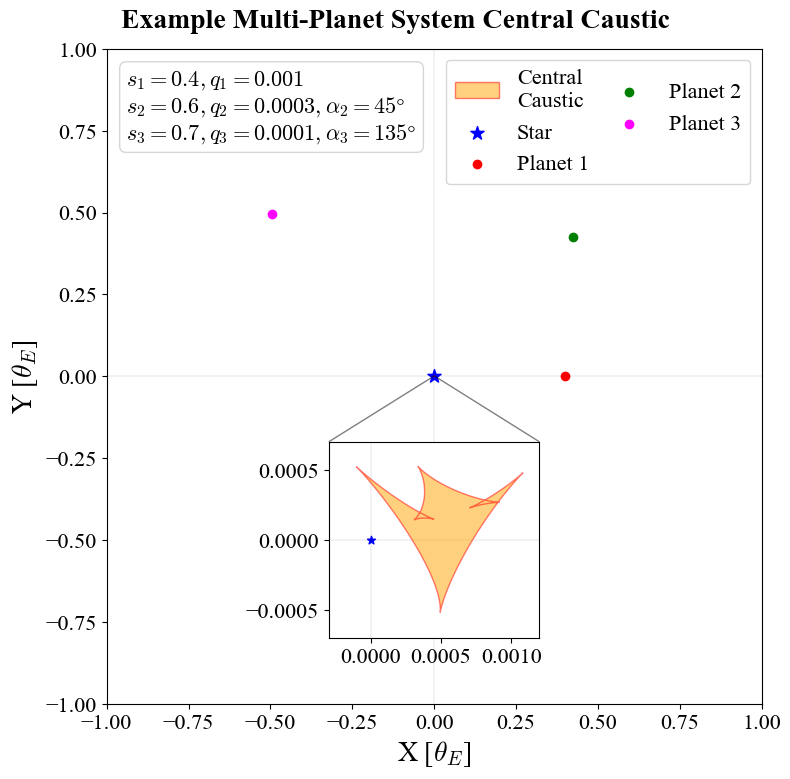

In [252]:
s1 = 0.4
q1 = 1e-3
alpha1 = 0
s2 = 0.6
q2 = 3e-4
alpha2 = 45
s3 = 0.7
q3 = 1e-4
alpha3 = 135

lens_attributes = np.array([
    [0, 0, 1],
    [s1*np.cos(np.deg2rad(alpha1)), s1*np.sin(np.deg2rad(alpha1)), q1],
    [s2*np.cos(np.deg2rad(alpha2)), s2*np.sin(np.deg2rad(alpha2)), q2],
    [s3*np.cos(np.deg2rad(alpha3)), s3*np.sin(np.deg2rad(alpha3)), q3]
])

center_of_mass = np.average(lens_attributes[:, :2], axis=0, weights=lens_attributes[:, 2])
desired_offset = center_of_mass

# lens_attributes[:, :2] -= desired_offset
lens_attributes[:, :2] -= np.array([0, 0])

VBM.SetLensGeometry(lens_attributes.flatten().tolist())
caustics = VBM.Multicaustics()
caustics = np.array(caustics, dtype=object)

def plot_elements(target_ax, show_labels=False):
    x_c = caustics[0][0] + center_of_mass[0] - desired_offset[0]
    y_c = caustics[0][1] + center_of_mass[1] - desired_offset[1]
    points = np.array([x_c, y_c]).T
    kw = dict(label='Central Caustic') if show_labels else {}
    target_ax.add_patch(patches.Polygon(
        points, closed=False, fill=True,
        edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, **kw))

fig = plt.figure()
fig.set_tight_layout(True)
ax = fig.add_subplot()

fig.suptitle('Example Multi-Planet System Central Caustic', y=0.97)

x_c = caustics[5][0] + center_of_mass[0] - desired_offset[0]
y_c = caustics[5][1] + center_of_mass[1] - desired_offset[1]
points = np.array([x_c, y_c]).T

ax.add_patch(patches.Polygon(
    points, closed=False, fill=True,
    edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, label='Central\nCaustic'))

ax.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star', s=100)

colors = ['blue', 'red', 'green', 'magenta', 'cyan']

for i in range(1, len(lens_attributes)):
    ax.scatter(lens_attributes[i, 0], lens_attributes[i, 1], marker='o', color=colors[i], label=f'Planet {i}')

ax.set_aspect('equal')
view = 1
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

# Inset 1: Central caustic magnification [-0.05, 0.05] x [-0.05, 0.05]
axins1 = ax.inset_axes([0.3, 0.1, 0.4, 0.3])
axins1.add_patch(patches.Polygon(
    points, closed=False, fill=True,
    edgecolor='red', facecolor='orange', alpha=0.5, zorder=5, label='Central\nCaustic'))
axins1.scatter(lens_attributes[0, 0], lens_attributes[0, 1],
          color='blue', marker='*', label='Star')
axins1.set_xlim(-0.0003, 0.0012)
axins1.set_ylim(-0.0007, 0.0007)
axins1.set_aspect('equal')
axins1.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
axins1.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.indicate_inset_zoom(axins1, edgecolor='black')

ax.legend(ncol=2, loc='upper right', columnspacing=0.8)

text_str = '\n'.join([
    f'$s_1 = {s1}, q_1 = {q1}$',
    f'$s_2 = {s2}, q_2 = {q2}, \\alpha_2 = {alpha2} \\degree$',
    f'$s_3 = {s3}, q_3 = {q3}, \\alpha_3 = {alpha3} \\degree$'
])

ax.text(0.03, 0.97, text_str, transform=ax.transAxes,
        fontsize=16, ha='left', va='top', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round', edgecolor='0.8'))

fig.savefig('./Figures/Multi-Planet Caustic Example.png', dpi=300)

plt.show()